# Heatmap

In [1]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
import numpy as np
warnings.filterwarnings("ignore")

StatementMeta(, a5959775-24b3-4704-8765-eb62d8b108ea, 3, Finished, Available, Finished, False)

In [2]:
%run ./peak_plot

StatementMeta(, a5959775-24b3-4704-8765-eb62d8b108ea, 4, Finished, Available, Finished, True)

In [3]:
match_method = "calendar2_1year"

# =====================================================
# Load matching result
# =====================================================

matches = pd.read_parquet(
    f"/lakehouse/default/Files/output/matching_high/{match_method}/matches"
)

matches["cohort"] = pd.to_datetime(matches["adoption_month"]).dt.to_period("M")

treated_ids = matches["treated_id"].unique()
control_ids = matches["control_id"].unique()

print(matches.head())
print(f"Treated IDs: {len(treated_ids)}")
print(f"Matched control IDs: {len(control_ids)}")


# =====================================================
# Load full monthly data
# IMPORTANT: keep this as full sample
# =====================================================

month_result_full = pd.read_parquet("/lakehouse/default/Files/month_data")

print("Full month_result:", month_result_full.shape)
print("Full households:", month_result_full["aID"].nunique())


# =====================================================
# Construct matched sample mapping
# =====================================================

treated_map = matches[["treated_id", "cohort"]].drop_duplicates().copy()
treated_map.columns = ["aID", "cohort"]
treated_map["treatment"] = 1

control_map = matches[["control_id", "cohort"]].copy()
control_map.columns = ["aID", "cohort"]
control_map["treatment"] = 0

match_map = pd.concat([treated_map, control_map], axis=0)

print(match_map.head())


# =====================================================
# Matched sample only
# Use this for main matched analysis
# =====================================================

month_result_matched = month_result_full.merge(
    match_map,
    on="aID",
    how="inner"
)

print("Matched month_result:", month_result_matched.shape)
print("Matched households:", month_result_matched["aID"].nunique())


# =====================================================
# Identify adopter / never adopter groups in full sample
# =====================================================

all_adopter_ids = month_result_full.loc[
    month_result_full["tariff_start"].notna(), "aID"
].unique()

all_never_ids = month_result_full.loc[
    month_result_full["tariff_start"].isna(), "aID"
].unique()

matched_never_ids = control_ids

unmatched_never_ids = np.setdiff1d(
    all_never_ids,
    matched_never_ids
)

print(f"All adopters: {len(all_adopter_ids)}")
print(f"All never adopters: {len(all_never_ids)}")
print(f"Matched never adopters: {len(matched_never_ids)}")
print(f"Unmatched never adopters: {len(unmatched_never_ids)}")


StatementMeta(, a5959775-24b3-4704-8765-eb62d8b108ea, 5, Finished, Available, Finished, False)

           treated_id          control_id adoption_month  distance  valid_dim  \
0  735999166200137406  735999166201588467     2025-10-01  0.056840          5   
1  735999166200137406  735999166200200018     2025-10-01  0.056862          5   
2  735999166200137406  735999166202144495     2025-10-01  0.061165          5   
3  735999166200137406  735999166204733253     2025-10-01  0.061480          5   
4  735999166200137406  735999166202887996     2025-10-01  0.068502          5   

   match_rank   cohort  
0           1  2025-10  
1           2  2025-10  
2           3  2025-10  
3           4  2025-10  
4           5  2025-10  
Treated IDs: 1696
Matched control IDs: 7527
Full month_result: (4538578, 17)
Full households: 48930
                   aID   cohort  treatment
0   735999166200137406  2025-10          1
5   735999166200193587  2025-10          1
10  735999166200271612  2025-10          1
15  735999166200436967  2025-10          1
20  735999166200437223  2025-10          1
Match

StatementMeta(, a5959775-24b3-4704-8765-eb62d8b108ea, 6, Finished, Available, Finished, False)

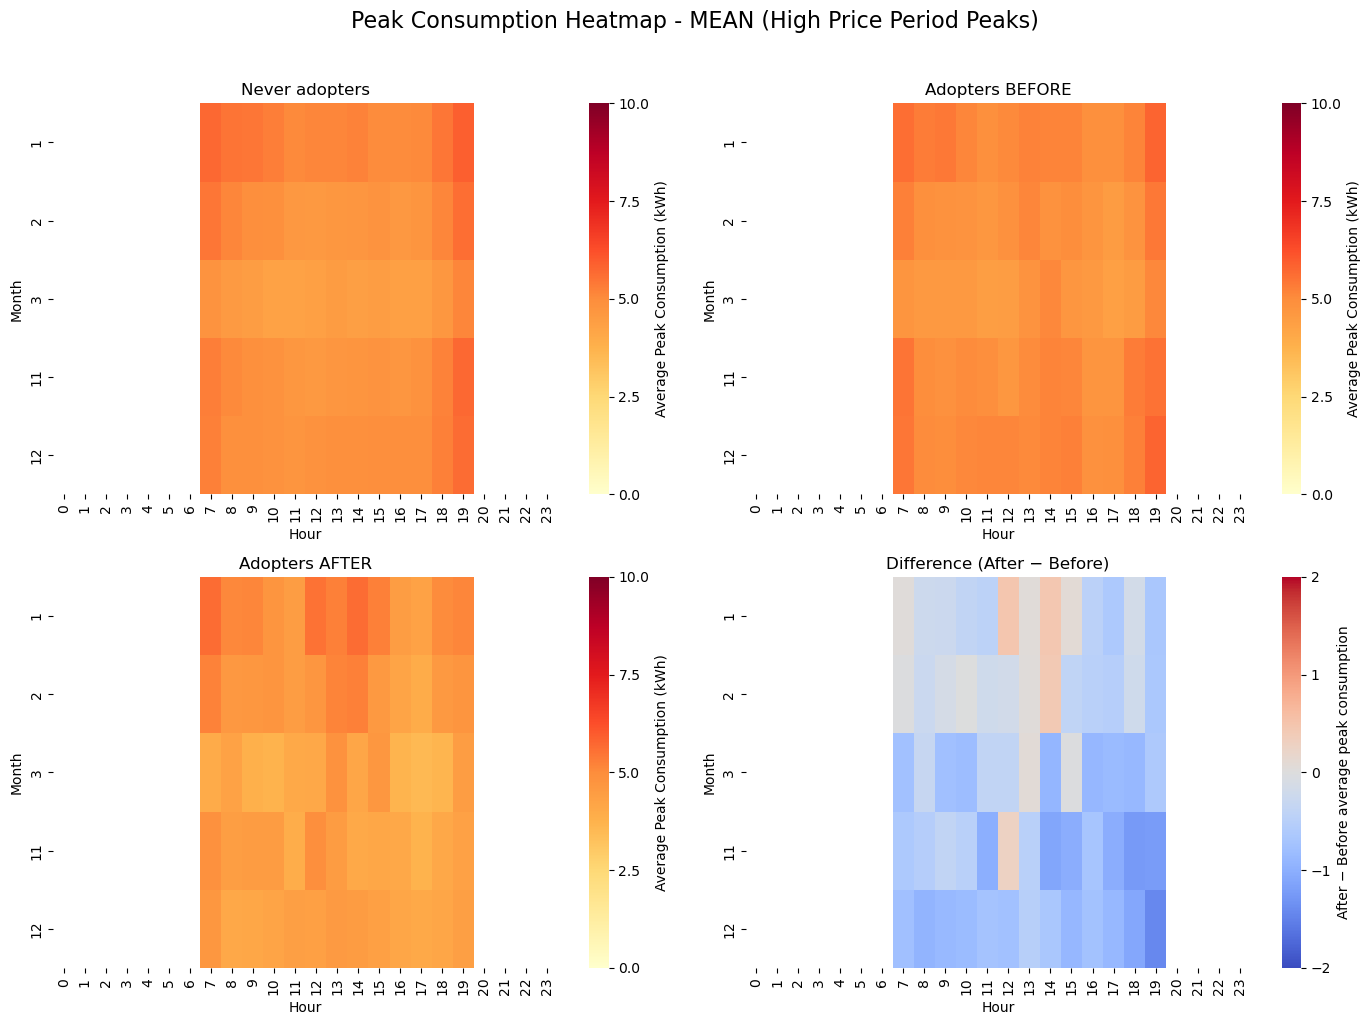

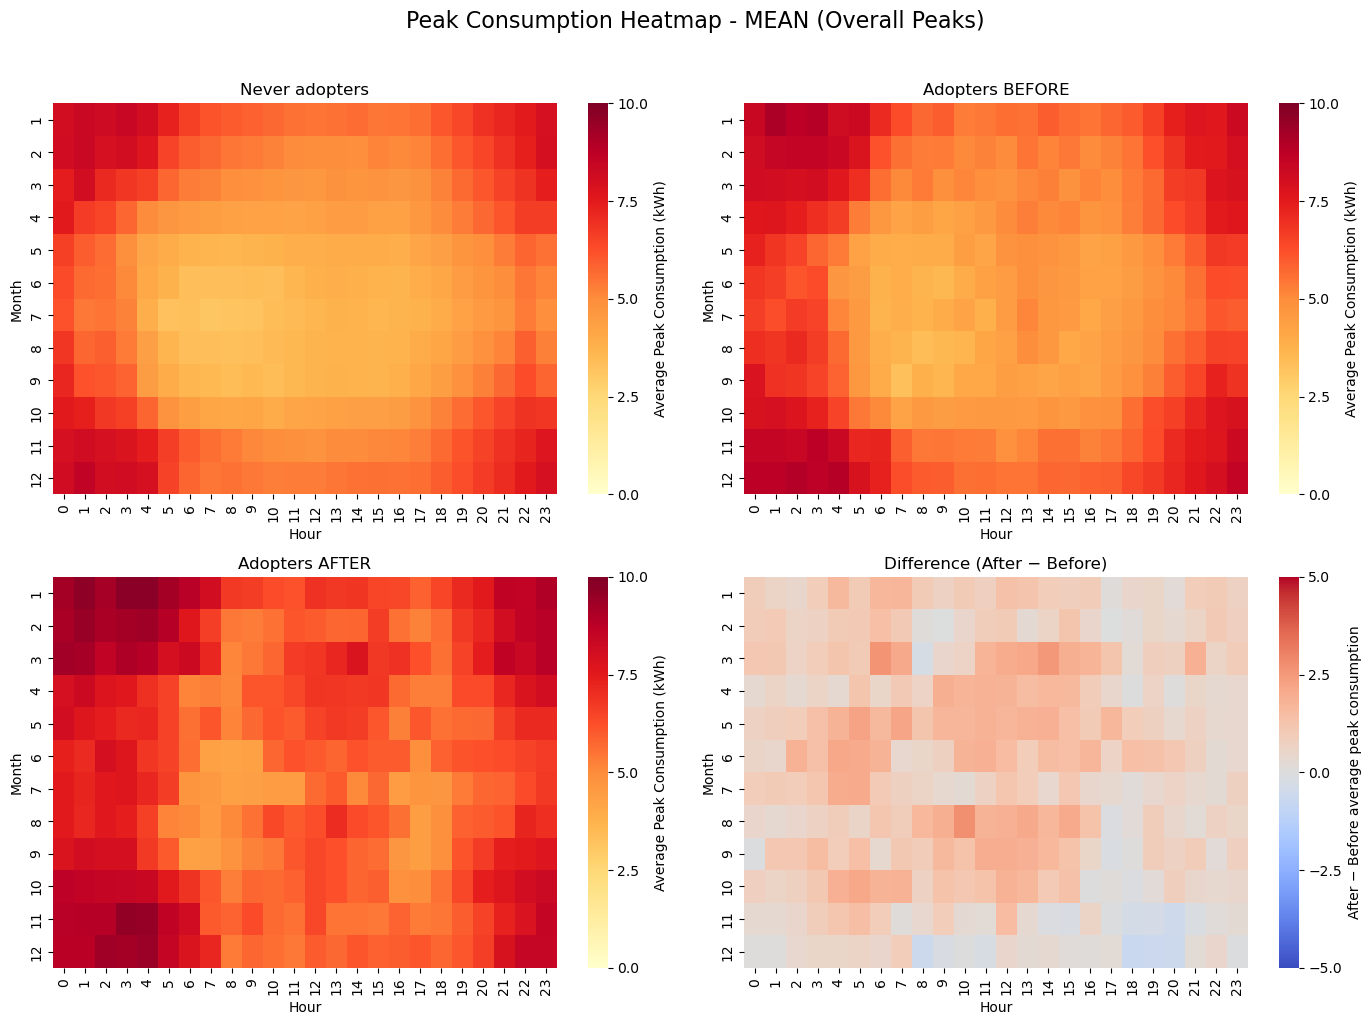

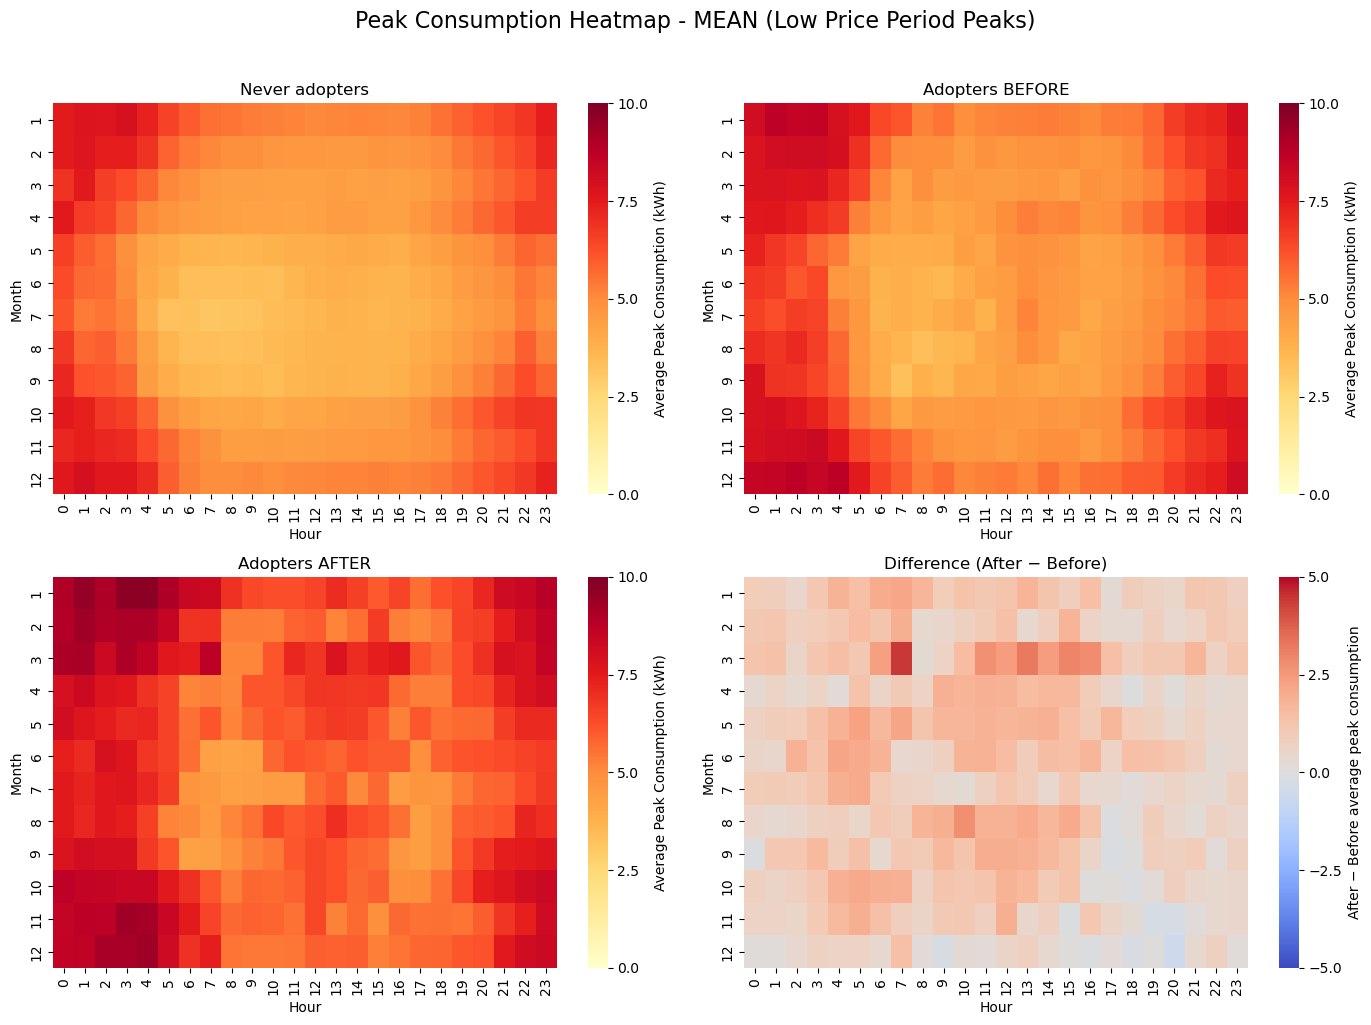

In [4]:
# Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result_matched[month_result_matched["price"] == "high"],
    price_label="high"
)

plot_tariff_consumption_heatmap(
    month_result_matched[month_result_matched["price"] == "all"],
    price_label="all"
)

plot_tariff_consumption_heatmap(
    month_result_matched[month_result_matched["price"] == "low"],
    price_label="low"
)

1×2
Everyone overall consumption (Before tariff)
Everyone overall consumption (After tariff)

1×4
All never adopters
All adopters (Before tarff)
Matched never adopters
Unmatched never adopters

In [8]:
df_all_full

StatementMeta(, a5959775-24b3-4704-8765-eb62d8b108ea, 11, Finished, Available, Finished, False)

,aID,TIDPUNKT,price,tariff_active,peak1_time,peak1_consumption,peak2_time,peak2_consumption,peak3_time,peak3_consumption,top3_mean_consumption,variance_consumption,mean_consumption,tariff_start,tariff_plan,total_consumption,usage_group
0,735999166200085868,2023-07-01,all,0,2023-07-31 18:00:00,1.51100000,2023-07-25 18:00:00,1.45000000,2023-07-26 18:00:00,1.40600000,1.455667,0.041173,0.183905913978,NaT,None,7459.16400000,low
2,735999166200085868,2023-02-01,all,0,2023-02-27 13:00:00,1.88000000,2023-02-21 13:00:00,1.81000000,2023-02-13 19:00:00,1.71000000,1.800000,0.080385,0.281845238095,NaT,None,7459.16400000,low
7,735999166200085868,2024-09-01,all,0,2024-09-05 16:00:00,1.97700000,2024-09-13 17:00:00,1.91500000,2024-09-23 17:00:00,1.74400000,1.878667,0.076012,0.257726388889,NaT,None,7459.16400000,low
9,735999166200085868,2024-06-01,all,0,2024-06-21 12:00:00,2.58000000,2024-06-08 17:00:00,2.27200000,2024-06-03 17:00:00,2.26000000,2.370667,0.118118,0.313034722222,NaT,None,7459.16400000,low
11,735999166200085868,2023-10-01,all,0,2023-10-20 12:00:00,2.42300000,2023-10-30 14:00:00,1.91000000,2023-10-27 17:00:00,1.84500000,2.059333,0.085199,0.306268817204,NaT,None,7459.16400000,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4538569,735999166300928010,2024-09-01,all,0,2024-09-15 16:00:00,7.47200000,2024-09-28 01:00:00,6.80300000,2024-09-27 23:00:00,6.64700000,6.974000,2.227857,1.322545833333,NaT,None,25498.93100000,medium
4538571,735999166300928010,2025-03-01,all,0,2025-03-04 20:00:00,6.63400000,2025-03-18 21:00:00,6.58600000,2025-03-01 22:00:00,6.42900000,6.549667,2.385975,1.774776261937,NaT,None,25498.93100000,medium
4538572,735999166300928010,2025-09-01,all,0,2025-09-12 11:00:00,6.51900000,2025-09-10 01:00:00,6.40100000,2025-09-07 00:00:00,6.32900000,6.416333,2.228294,1.340270833333,NaT,None,25498.93100000,medium
4538575,735999166300928010,2025-05-01,all,0,2025-05-05 06:00:00,7.73100000,2025-05-10 15:00:00,7.03600000,2025-05-24 14:00:00,6.86000000,7.209000,2.672881,1.491432795699,NaT,None,25498.93100000,medium


StatementMeta(, a5959775-24b3-4704-8765-eb62d8b108ea, 7, Finished, Available, Finished, False)

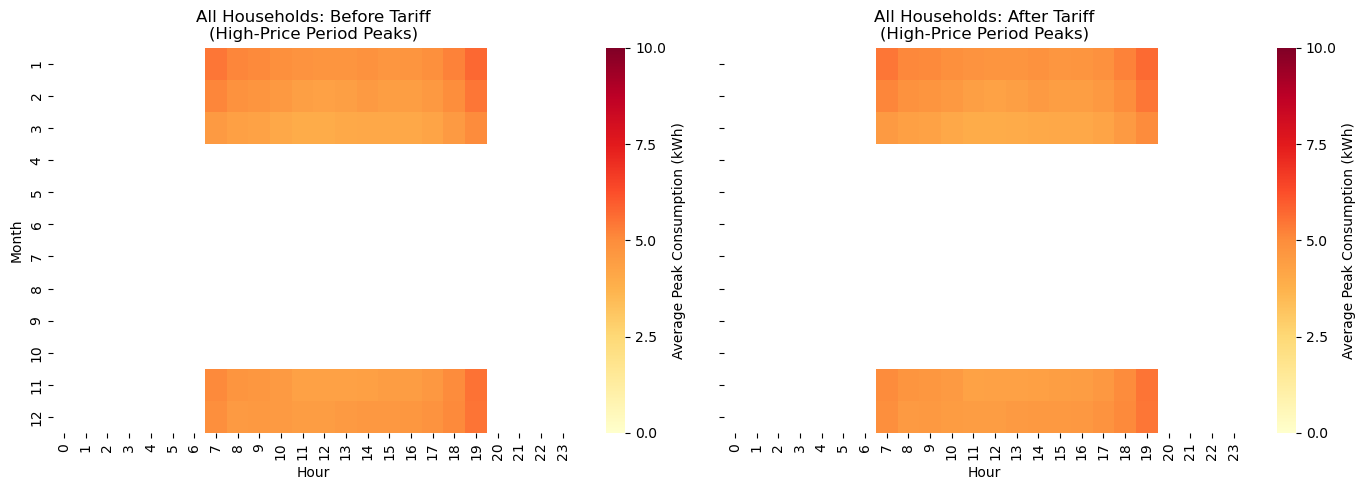

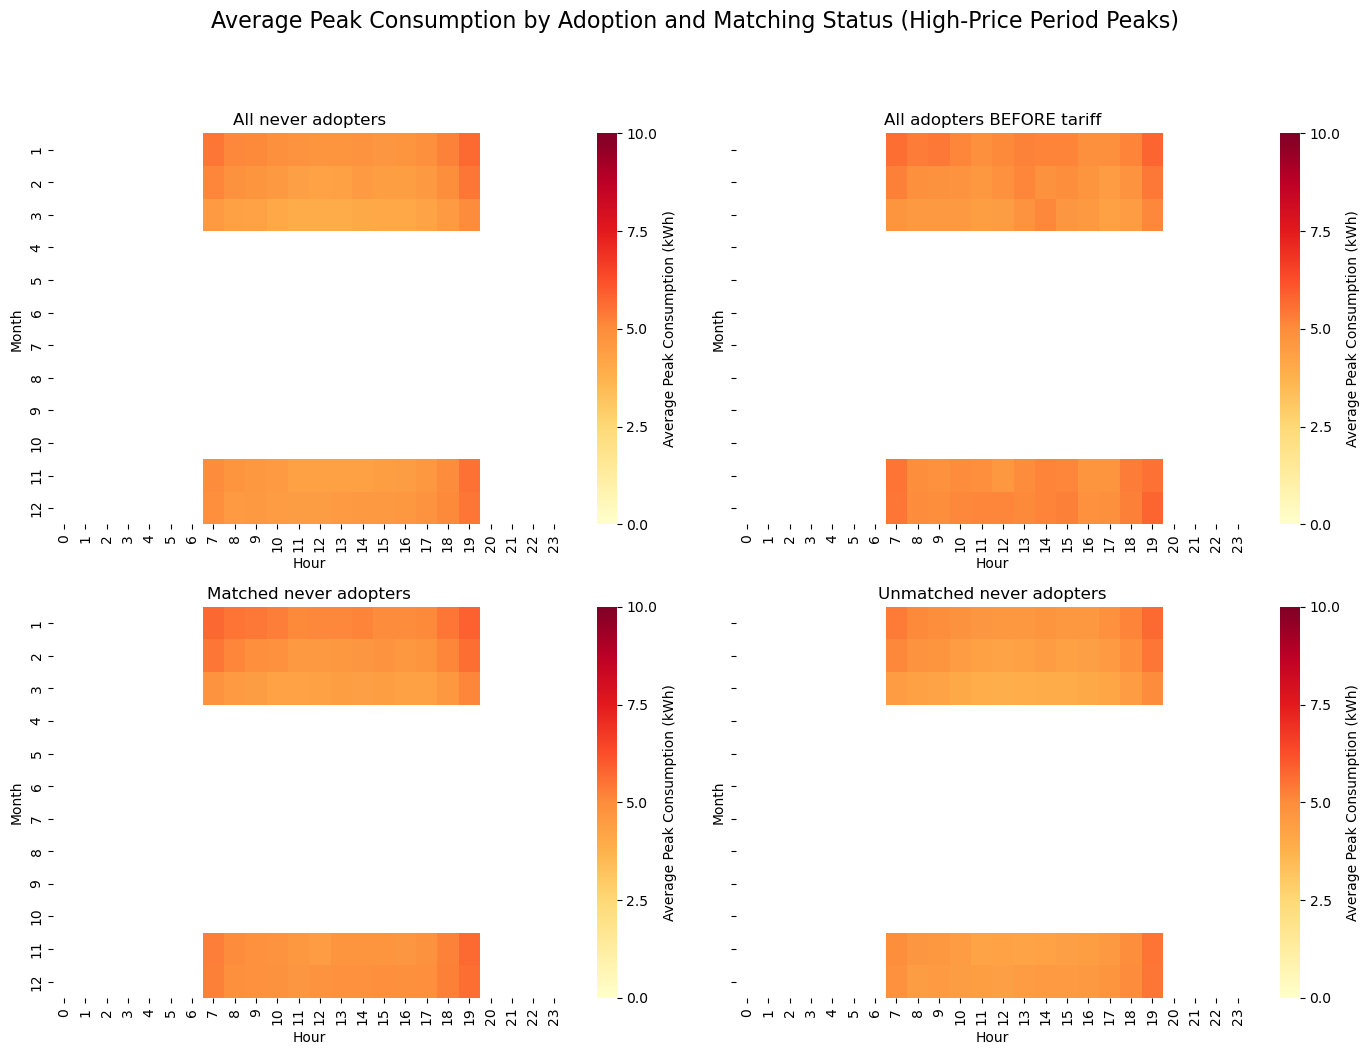

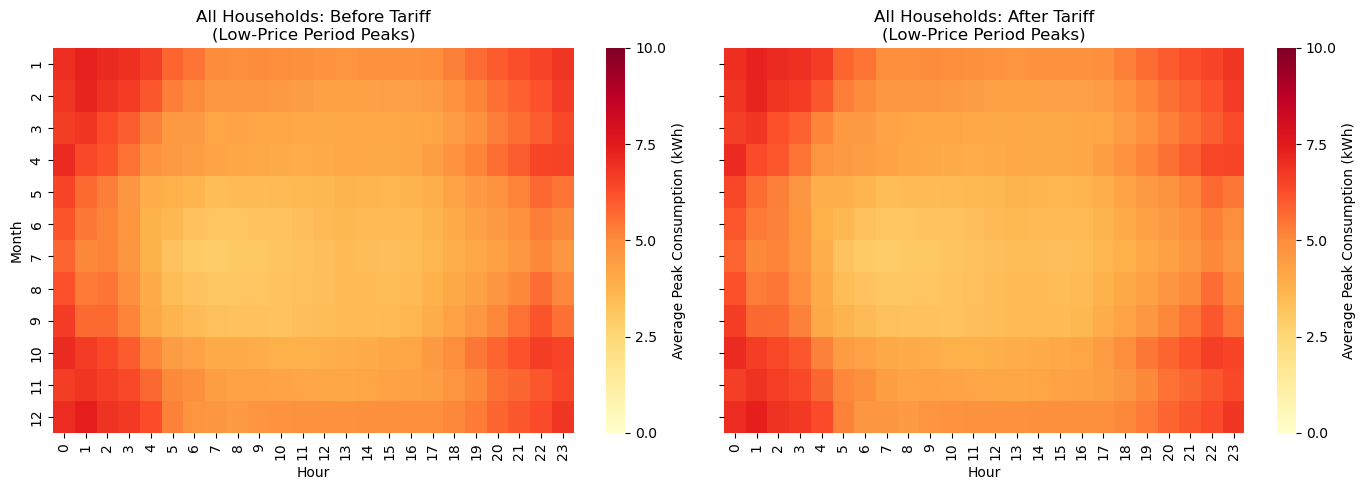

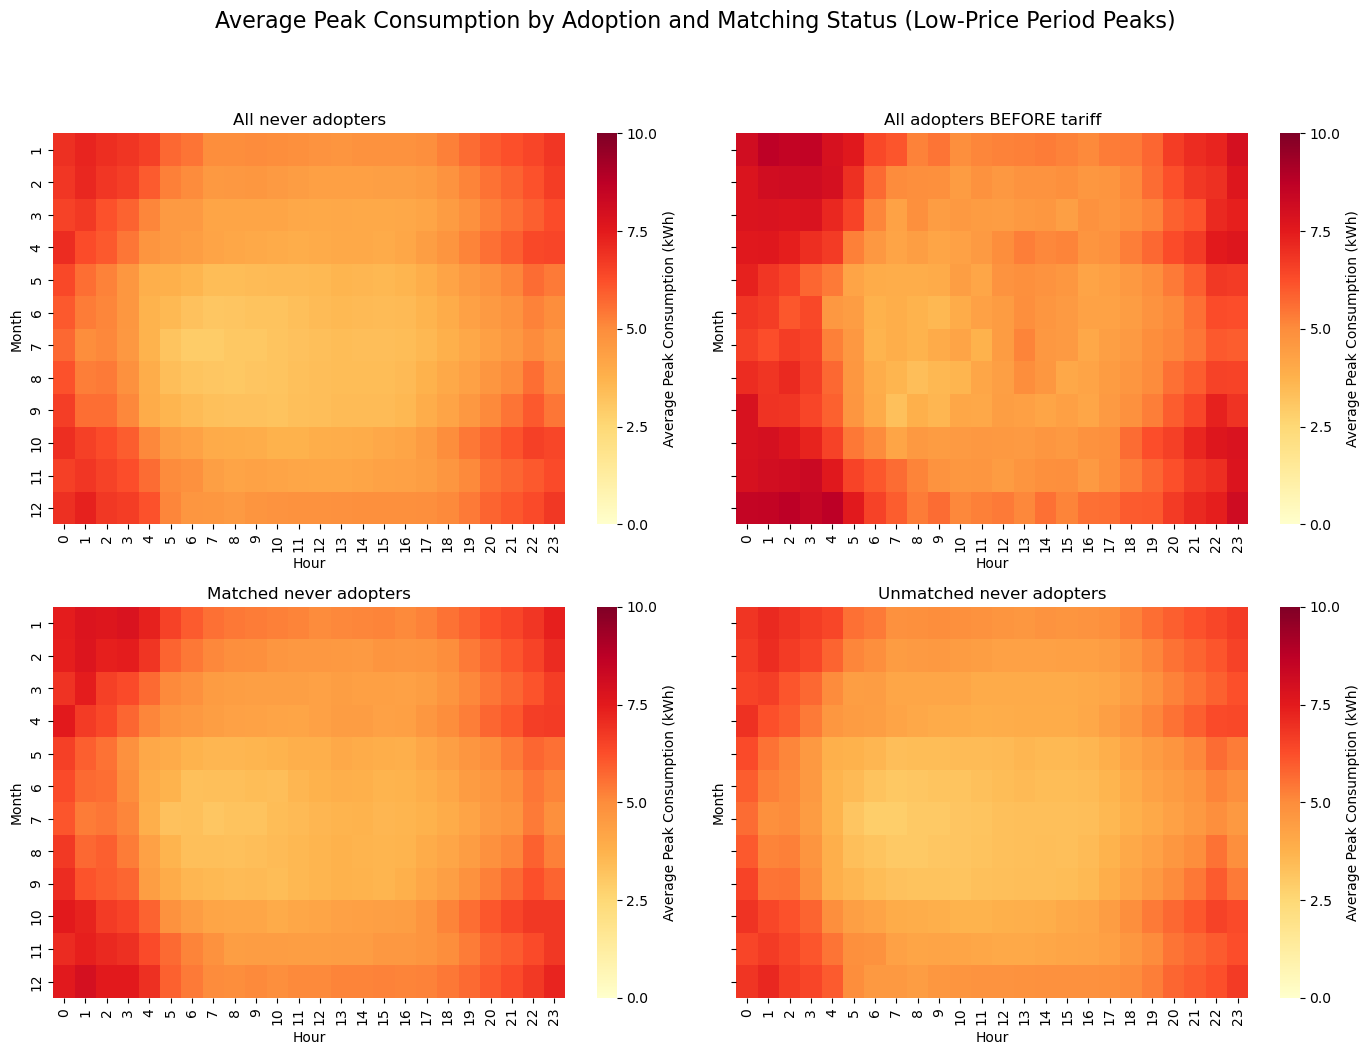

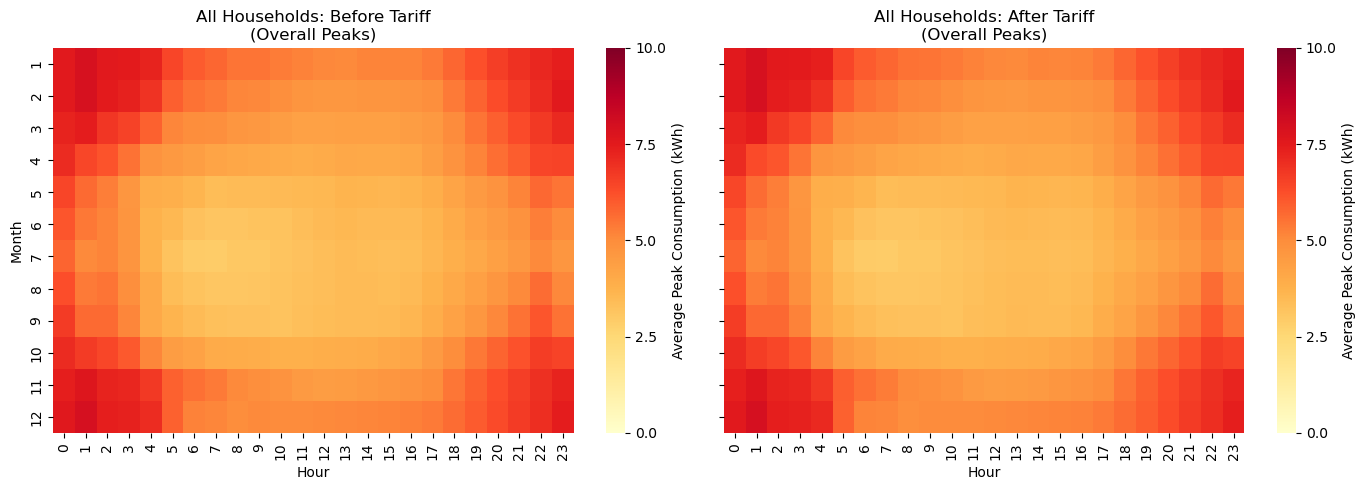

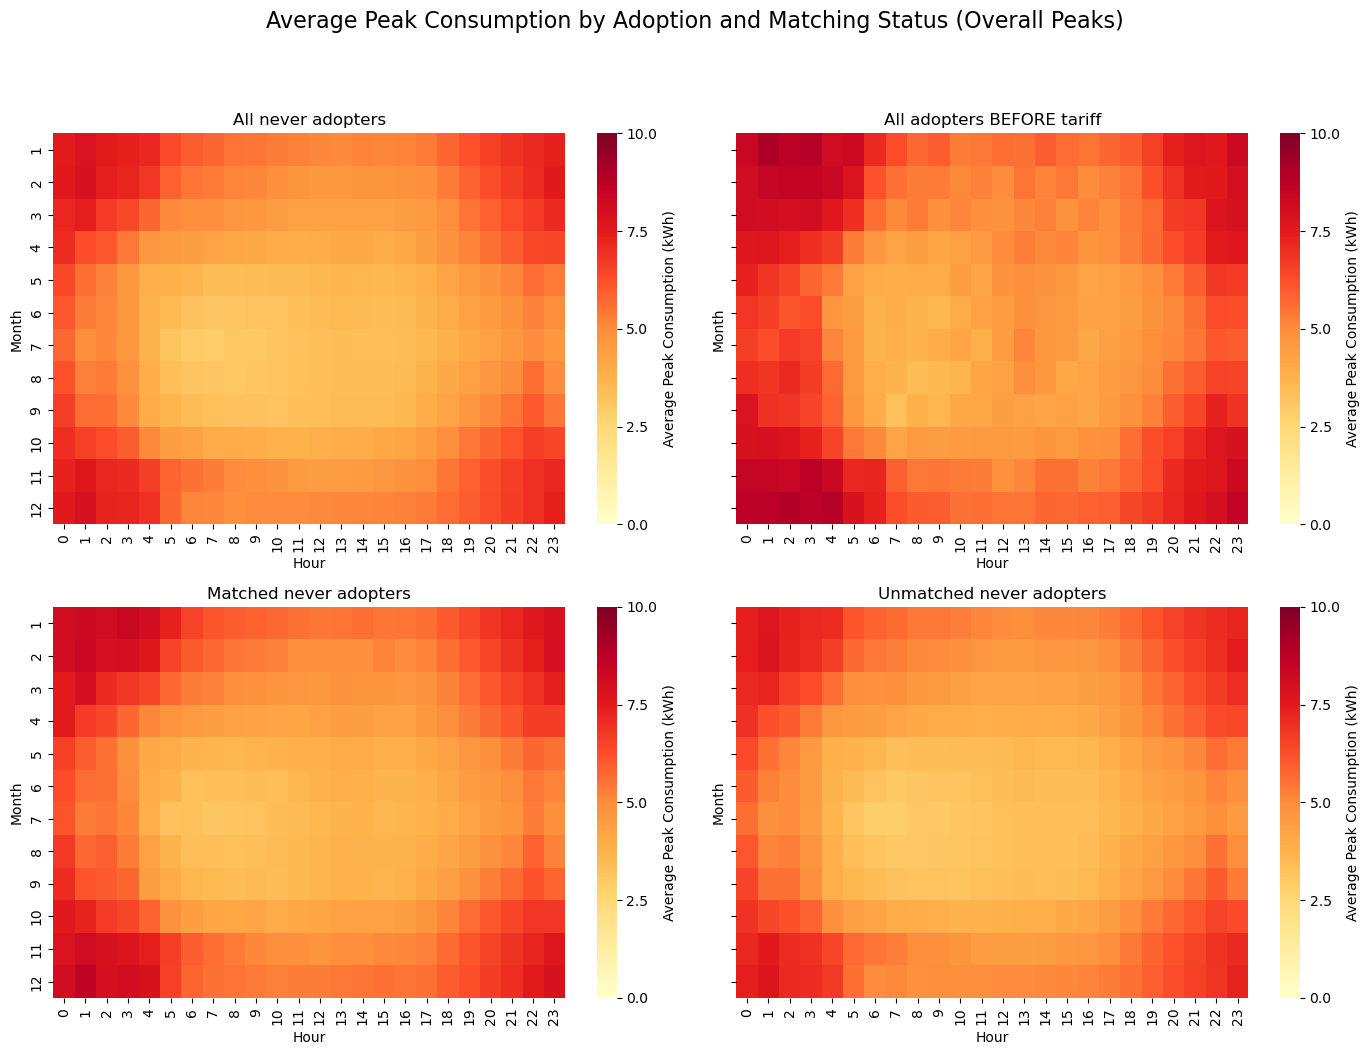

In [5]:
df_high_full = month_result_full[month_result_full["price"] == "high"].copy()
df_low_full  = month_result_full[month_result_full["price"] == "low"].copy()
df_all_full  = month_result_full[month_result_full["price"] == "all"].copy()

common_vmax_population = get_population_heatmap_common_vmax(
    dfs=[df_high_full, df_low_full, df_all_full],
    matched_control_ids=matched_never_ids
)

for df, label in [
    (df_high_full, "high"),
    (df_low_full, "low"),
    (df_all_full, "all")
]:
    plot_all_households_before_after_heatmap(
        df,
        price_label=label,
        consumption_vmax=common_vmax_population
    )

    plot_matching_status_heatmaps(
        df,
        matched_control_ids=matched_never_ids,
        price_label=label,
        consumption_vmax=common_vmax_population
    )